<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/05.5_Linear_Models_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 5 - Model Linier dan Regularisasi (Linear Models and Regularization)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 5 Linear Models and Regularization** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

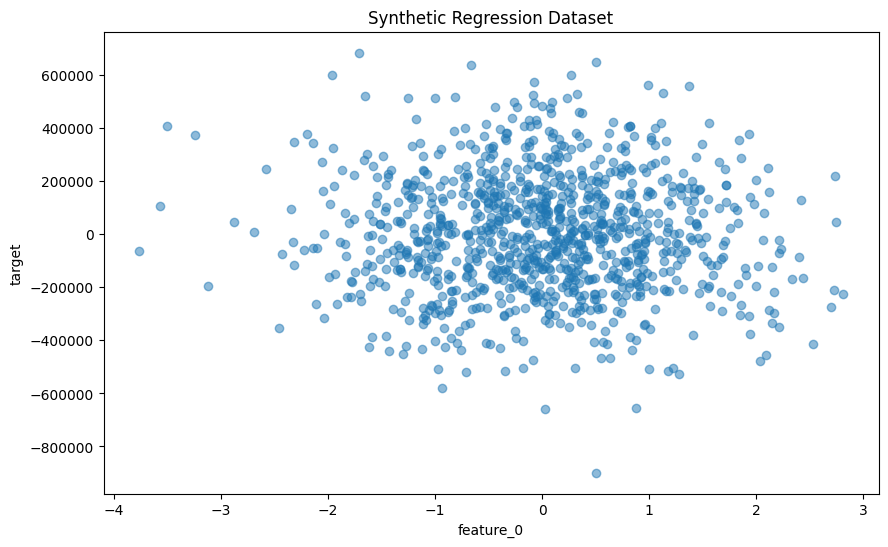

In [1]:
# Memuat perpustakaan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Buat kumpulan data regresi sintetik dengan multikolinearitas tinggi dan fitur lebih banyak
X, y = make_regression(n_samples=1000,
                      n_features=100,     
                      n_informative=10,   
                      noise=20,           
                      random_state=123)

# Tambahkan multikolinearitas dengan membuat fitur yang berkorelasi
for i in range(50, 100):  # Make half the features correlated
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

# Buat nama fitur
feature_names = [f'feature_{i}' for i in range(100)]

# Ambil saja fitur pertama untuk visualisasi
X_plot = X[:, 0].reshape(-1, 1)

# Tambahkan beberapa non-linearitas dan buat koefisiennya sangat bervariasi
y = y * 1000  # Scale up the target
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel()/10)

# Konversikan ke pandas DataFrame dengan nama fitur
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df_plot = pd.DataFrame({'feature_0': X_plot.ravel(), 'target': y})

# Visualisasi data yang cepat
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

### Bagaimana cara melakukannya
Penerapan model regresi linier sangatlah mudah. Kita akan menggunakan fungsi train_test_split() untuk membagi data menjadi set pelatihan dan pengujian, lalu menyesuaikan model regresi linier ke data latih. Terakhir, kita akan mengevaluasi performa model menggunakan metrik mean squared error (MSE) dan R-squared (R^2). Kami juga dapat memvisualisasikan prediksi model pada set pengujian untuk melihat seberapa cocok model tersebut dengan data.

Mean Squared Error: 46514258212.25
R-squared: 0.07


C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


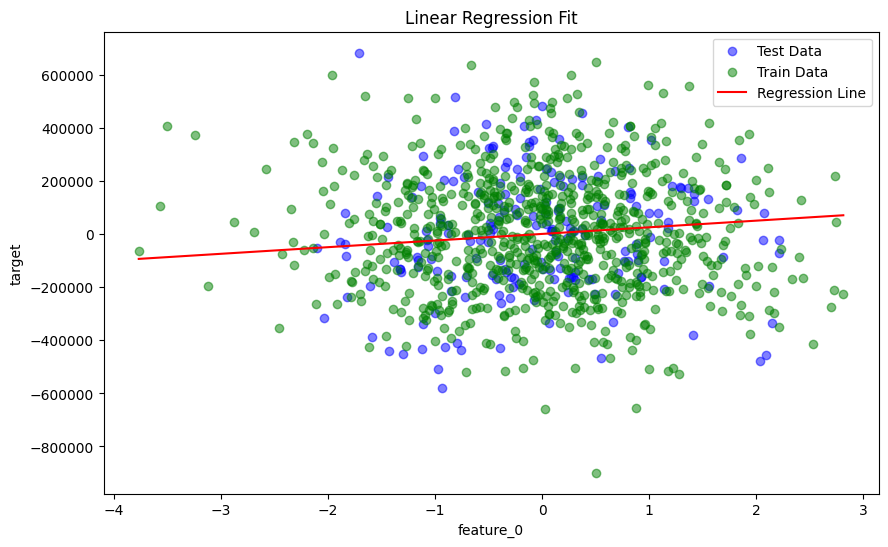

In [2]:
# Memuat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Bagi menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Membuat dan menyesuaikan model Regresi Linier
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Buatlah prediksi pada set tes
y_pred = linear_model.predict(X_test)

# Evaluasi kinerja menggunakan MSE dan R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# Visualisasikan data dan garis regresi (menggunakan feature_0 untuk visualisasi)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')

# Urutkan data untuk plot garis halus
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()  # Set feature_0, leave others as 0
y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

### Cara kerjanya
Regresi linier adalah teknik mendasar yang digunakan untuk memodelkan hubungan antara variabel terikat (target) dan satu atau lebih variabel bebas (fitur). Model tersebut mengasumsikan adanya hubungan linier antara variabel-variabel tersebut

## Ridge Regression dan Lasso

### Bersiap
Untuk mengimplementasikan regresi Ridge dan Lasso, kita akan menggunakan kelas Ridge dan Lasso dari modul sklearn.linear_model. Kelas-kelas ini mirip dengan `LinearRegression()`, tetapi mereka menyertakan parameter tambahan yang disebut alpha, yang mengontrol kekuatan regularisasi. Kita dapat menggunakan kumpulan data yang sama yang dibuat di bagian sebelumnya untuk mendemonstrasikan penerapan regresi Ridge dan Lasso.

### Bagaimana cara melakukannya
Mari kita sesuaikan model regresi Ridge dan Lasso dengan data dan bandingkan hasilnya dengan model regresi linier yang kita buat di bagian sebelumnya. Anda akan melihat bahwa model Ridge dan Lasso berkinerja lebih baik daripada model regresi linier, namun perbedaannya tidak signifikan seperti yang Anda harapkan. Hal ini karena datanya sangat multikolinear dan fitur-fiturnya sangat berkorelasi satu sama lain.

,Model,Mean Squared Error,R-squared
0,Ridge Regression,45299333022.45,0.09
1,Lasso Regression,46407932951.33,0.07
2,Linear Regression,46514258212.25,0.07


C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


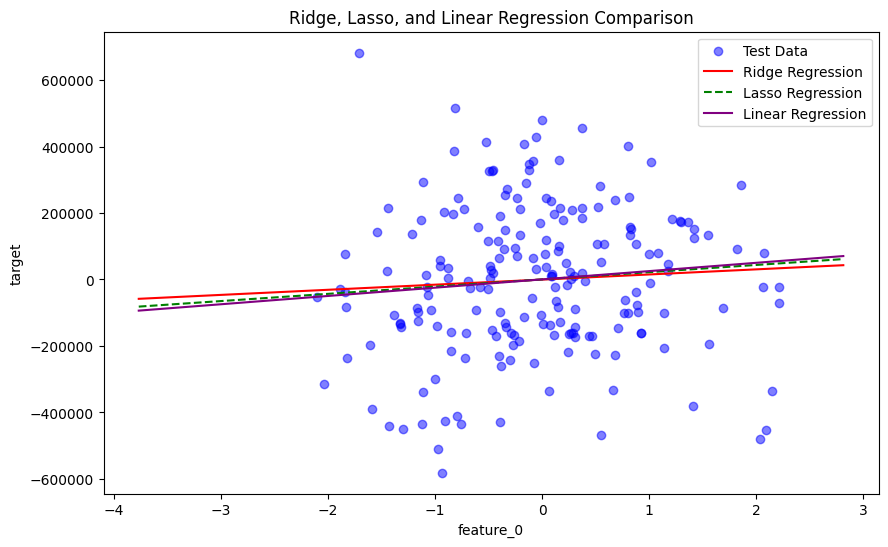

In [3]:
# Memuat perpustakaan
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Buat dan sesuaikan model regresi Ridge
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

# Buat dan sesuaikan model regresi Lasso dengan peningkatan iterasi dan alfa
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Buat prediksi dengan kedua model
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluasi kinerja
y_pred_linear = linear_model.predict(X_test)

# Hitung metrik untuk semua model
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_linear)
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso), 
        r2_score(y_test, y_pred_linear)
    ]
}

# Buat DataFrame dan urutkan berdasarkan MSE
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format kolom numerik
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

display(metrics_df)

# Visualisasikan hasilnya (menggunakan feature_0 untuk visualisasi)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')

# Urutkan data untuk plot garis halus
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

# Hasilkan prediksi untuk garis tersebut
y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, color='red', label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple', label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

## ElasticNet dan Regularisasi 

### Bersiap
Untuk mengimplementasikan regresi ElasticNet, kita akan menggunakan kelas ElasticNet dari modul sklearn.linear_model. Kelas ini mirip dengan regresi Ridge dan Lasso, tetapi kelas ini menggabungkan kekuatannya untuk menangani berbagai jenis data. Kita dapat menggunakan kumpulan data yang sama yang dibuat di bagian sebelumnya untuk mendemonstrasikan penerapan regresi ElasticNet. 

### Bagaimana cara melakukannya
Kita akan membuat rentang nilai `alpha` dan `l1_ratio` untuk menguji dan memplot jalur koefisien untuk setiap kombinasi. Ini adalah tujuan utama ElasticNet, untuk menangani multikolinearitas dan data berdimensi tinggi yang umum terjadi pada kumpulan data dunia nyata. Visualisasi yang dihasilkan disebut "plot jalur koefisien" dan menunjukkan hubungan antara alfa dan koefisien untuk setiap fitur.

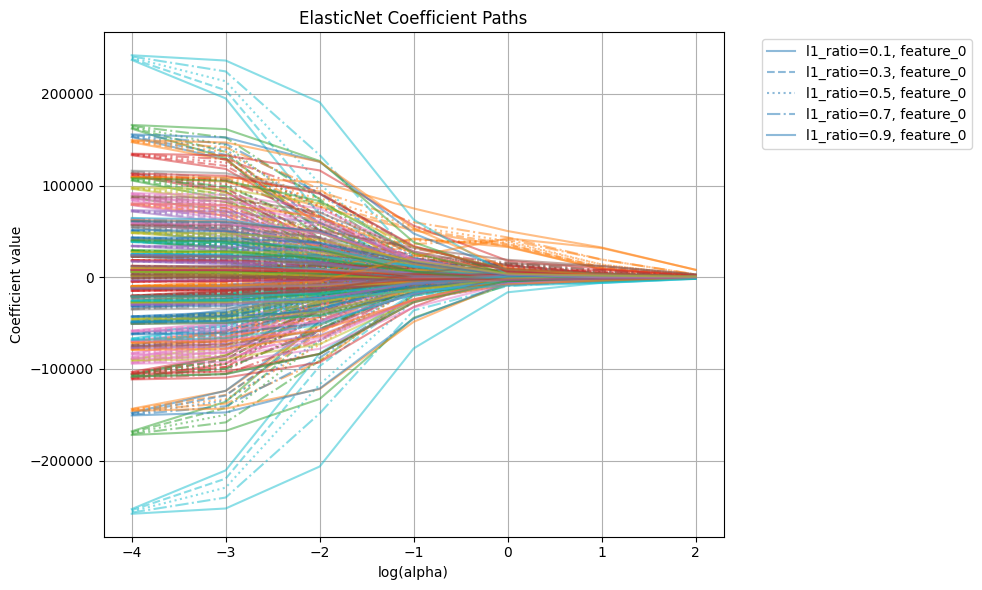

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,42651249835.44,0.14
0,Ridge Regression,45299333022.45,0.09
1,Lasso Regression,46407932951.33,0.07
2,Linear Regression,46514258212.25,0.07


In [4]:
# Memuat perpustakaan
from sklearn.linear_model import ElasticNet

# Buat rentang alfa untuk diuji
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Simpan koefisien untuk membuat plot
coef_paths = []
labels = []

# Membuat dan menyesuaikan model ElasticNet dengan parameter berbeda
plt.figure(figsize=(10, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for alpha in alphas:
        # Buat dan sesuaikan model ElasticNet dengan peningkatan max_iter dan tol
        elastic_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123,
                                 max_iter=10000, tol=1e-4)
        elastic_model.fit(X_train, y_train)
        coefs.append(elastic_model.coef_)
    
    # Ubah koefisien menjadi array dan simpan
    coef_paths.append(np.array(coefs))
    
    # Jalur koefisien plot
    for feature_idx in range(X_train.shape[1]):
        plt.plot(np.log10(alphas), 
                np.array(coefs)[:, feature_idx], 
                label=f'l1_ratio={l1_ratio}, feature_{feature_idx}' if feature_idx == 0 else "",
                alpha=0.5,
                linestyle=['solid', 'dashed', 'dotted', 'dashdot', '-'][l1_ratios.index(l1_ratio)])

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Buat model dengan l1_ratio seimbang dan alpha sedang
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123,
                          max_iter=10000, tol=1e-4)  
elastic_model.fit(X_train, y_train)

# Hitung metrik
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

# Tambahkan hasil ElasticNet ke metrik DataFrame
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'Mean Squared Error': [elastic_mse],
    'R-squared': [elastic_r2]
})

# Hapus semua entri ElasticNet yang ada sebelum menggabungkan
metrics_df = metrics_df[~metrics_df['Model'].str.contains('ElasticNet')]

# Ubah nilai string kembali menjadi float untuk penyortiran
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].astype(float)
metrics_df['R-squared'] = metrics_df['R-squared'].astype(float)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Urutkan metrik DataFrame berdasarkan Mean Squared Error
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format kolom numerik untuk ditampilkan
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

# Tampilkan metrik yang diperbarui
display(metrics_df)

## Regresi Polinomial 

### Bersiap
Mari kita lanjutkan dan jelajahi regresi polinomial (termasuk interpolasi spline). Metode ini memperluas kemampuan regresi linier tradisional, memungkinkan pemodelan hubungan kompleks dalam data yang lebih fleksibel. Dengan menerapkan teknik ini, Anda dapat memperluas perangkat pendekatan Anda terhadap masalah regresi.

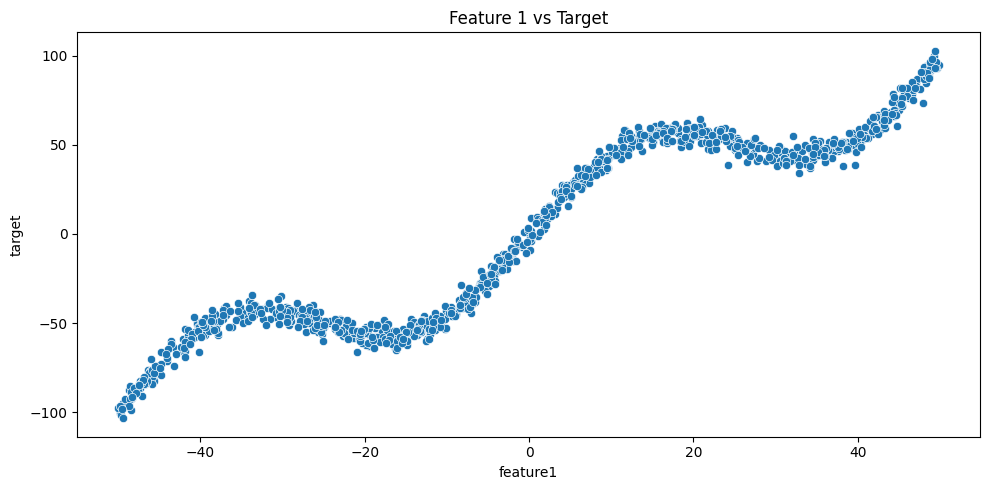

In [5]:
# Memuat perpustakaan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Buat kumpulan data sintetis dengan hubungan non-linier
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

# Buat target dengan komponen non-linier:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)  
     + np.random.normal(0, 4, n_samples))  # noise

# Buat Bingkai Data
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

# Buat plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

### Bagaimana cara melakukannya...
Pada kode di bawah, kita akan membuat daftar derajat polinomial untuk dicoba dan kemudian menyesuaikan model regresi linier pada fitur polinomial. Kami kemudian akan mengevaluasi performa model menggunakan metrik mean squared error (MSE) dan R-squared (R^2). Terakhir, kami akan memvisualisasikan berbagai kecocokan polinomial dan residu untuk model berperforma terbaik. Perlu diingat bahwa model yang berperforma terbaik tidak selalu model yang memiliki nilai R-kuadrat tertinggi, melainkan model yang paling sesuai dengan data dan memiliki rata-rata kesalahan kuadrat terendah. Selain itu, visualisasinya agak berantakan, tetapi ini adalah titik awal yang baik (Anda mungkin tidak akan menemukan kumpulan data dengan hubungan yang begitu bersih antara fitur dan target dengan nonlinier gelombang sinus yang sempurna).


Model Performance Metrics:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5  48.316167 0.983407


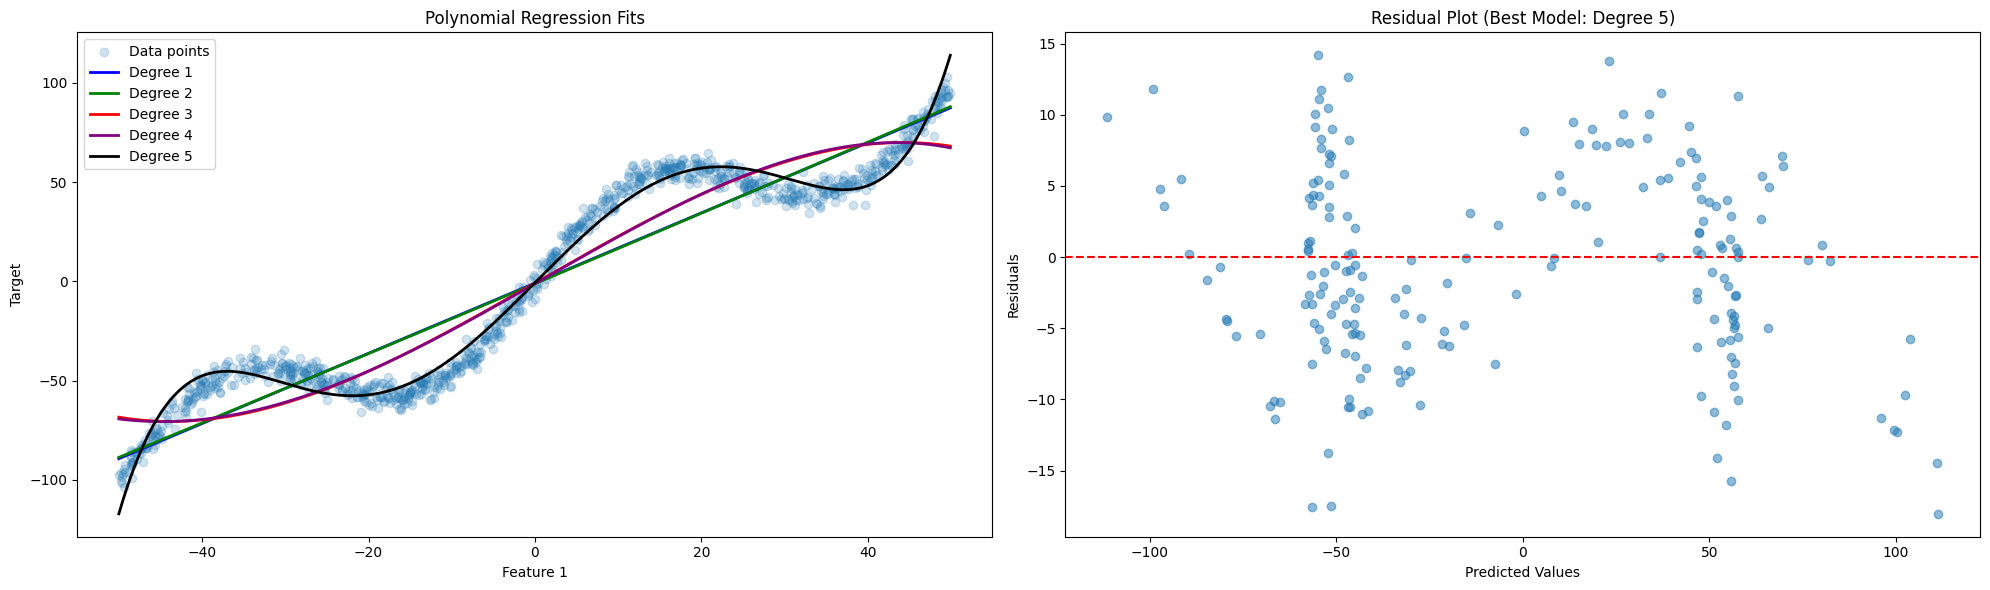

In [6]:
# Memuat perpustakaan
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Gunakan kumpulan data sintetis yang dibuat di atas
X = data[['feature1']]  
y = data['target']

# Buat daftar derajat polinomial untuk dicoba
degrees = [1, 2, 3, 4, 5]
results = []

# Coba derajat polinomial yang berbeda
for degree in degrees:
    # Ubah fitur menjadi fitur polinomial
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    # Bagi menjadi set pelatihan dan pengujian
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=123)
    
    # Membuat dan menyesuaikan model Regresi Linier pada fitur polinomial
    poly_model = LinearRegression()
    poly_model.fit(X_train, y_train)
    
    # Buatlah prediksi
    y_pred = poly_model.predict(X_test)
    
    # Hitung metrik
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Simpan hasil
    results.append({
        'Degree': degree,
        'MSE': mse,
        'R2': r2
    })

# Buat DataFrame hasil
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df.to_string(index=False))

# Buat visualisasi kecocokan polinomial yang berbeda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot data dan kecocokan polinomial
ax1.scatter(X['feature1'], y, alpha=0.2, label='Data points')

# Hasilkan poin untuk pembuatan kurva yang mulus
X_plot = np.linspace(X['feature1'].min(), X['feature1'].max(), 1000).reshape(-1, 1)

colors = ['blue', 'green', 'red', 'purple', 'black']
for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree)
    X_plot_poly = poly.fit_transform(X_plot)
    
    model = LinearRegression()
    model.fit(poly.fit_transform(X), y)
    y_plot = model.predict(X_plot_poly)
    
    ax1.plot(X_plot, y_plot, label=f'Degree {degree}', color=color, linewidth=2)

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits')
ax1.legend(loc='upper left')

# Plot residu untuk model berperforma terbaik (berdasarkan R2)
best_degree = results_df.loc[results_df['R2'].idxmax(), 'Degree']
best_poly = PolynomialFeatures(degree=best_degree)
X_poly_best = best_poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly_best, y, test_size=0.2, random_state=123)

best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residual Plot (Best Model: Degree {best_degree})')

plt.tight_layout()
plt.show()

### Interpolasi Spline 
Interpolasi spline adalah teknik yang digunakan untuk membuat kurva mulus yang melewati sekumpulan titik data. Ini adalah jenis interpolasi yang menggunakan polinomial sepotong-sepotong untuk memperkirakan data. Ide dasarnya adalah membagi data menjadi beberapa segmen, dan kemudian memasukkan polinomial ke setiap segmen. Kurva yang dihasilkan mulus dan kontinu pada titik-titik pertemuan segmen-segmen tersebut.

scikit-learn menyediakan kelas SplineTransformer yang dapat digunakan untuk membuat interpolasi spline. Kelas ini memungkinkan Anda menentukan jumlah "simpul" (titik pertemuan segmen) dan derajat polinomial yang digunakan untuk setiap segmen. Kelas SplineTransformer adalah bagian dari modul sklearn.preprocessing.

C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


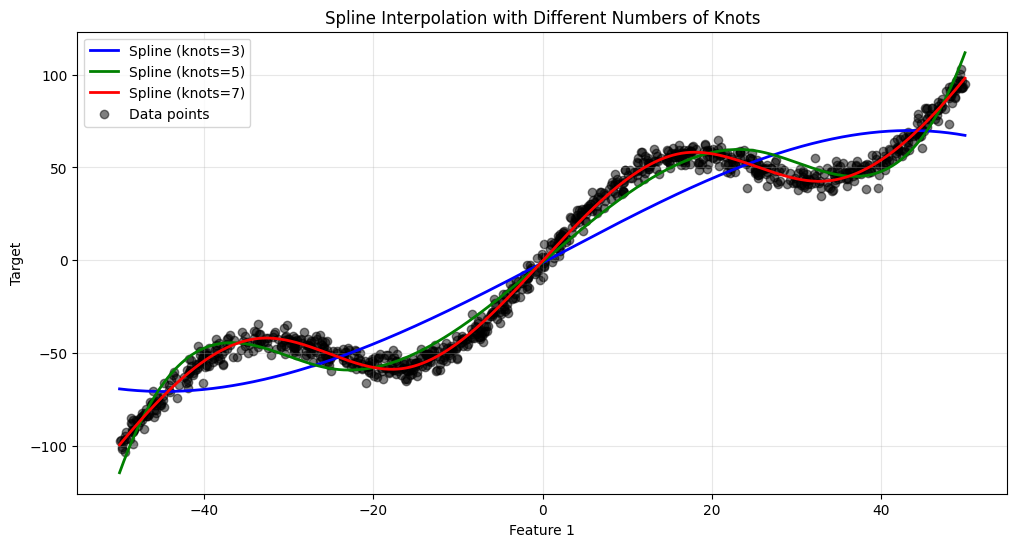

,Number of Knots,MSE,R-squared
0,3,274.267019,0.904652
1,5,55.347798,0.980759
2,7,15.502097,0.994611


In [7]:
# Memuat perpustakaan
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Buat trafo spline dengan derajat kebebasan berbeda
n_knots = [3, 5, 7]  # Different numbers of knots to try
plt.figure(figsize=(12, 6))

# Buat daftar untuk menyimpan metrik
mse_scores = []
r2_scores = []

for n_knot, color in zip(n_knots, colors[:len(n_knots)]):
    # Buat dan pasang trafo spline
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X, y)
    
    # Hasilkan prediksi
    y_pred = model.predict(X_plot)
    y_pred_train = model.predict(X)
    
    # Hitung metrik
    mse = mean_squared_error(y, y_pred_train)
    r2 = r2_score(y, y_pred_train)
    mse_scores.append(mse)
    r2_scores.append(r2)
    
    # Gambarkan hasilnya
    plt.plot(X_plot, y_pred, 
             label=f'Spline (knots={n_knot})', 
             color=color, 
             linewidth=2)

# Plot titik data asli
plt.scatter(X, y, color='black', alpha=0.5, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Membuat dan menampilkan metrik DataFrame
metrics_df = pd.DataFrame({
    'Number of Knots': n_knots,
    'MSE': mse_scores,
    'R-squared': r2_scores
})
display(metrics_df)


## Latihan Praktek dengan Model Linier dan Regularisasi

### Latihan 1: Menerapkan Regresi Punggungan
Pada eksekusi pertama, kita akan membuat kumpulan data baru dan menyesuaikan model regresi Ridge ke dalamnya. Kami kemudian akan mengevaluasi performa model menggunakan metrik mean squared error (MSE) dan R-squared (R^2). Terakhir, kami akan memvisualisasikan prediksi model pada set pengujian untuk melihat seberapa cocok model tersebut dengan data. Jika berlaku, pastikan untuk menggunakan random_state=123 dan/atau np.random.seed(123) untuk memastikan reproduktifitas.

Training Metrics:
MSE: 1.9780
R²: 0.6575

Test Metrics:
MSE: 2.5628
R²: -0.0360


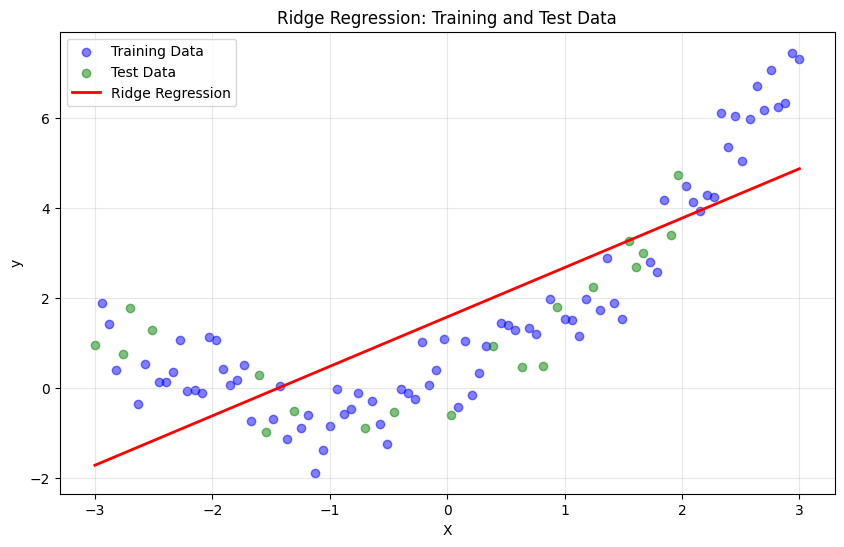

In [8]:
# Memuat perpustakaan
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Hasilkan kumpulan data sintetis dengan sedikit gangguan
np.random.seed(123)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X.ravel()**2 + X.ravel() + np.random.normal(0, 0.5, 100)

# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Buat dan sesuaikan model regresi Ridge
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge.fit(X_train, y_train)

# Buatlah prediksi
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

# Hitung metrik
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Cetak metrik
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualisasikan hasilnya
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Urutkan nilai X untuk plot garis halus
X_plot = np.sort(X, axis=0)
y_plot = ridge.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Ridge Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Latihan 2: Menerapkan Lasso Regression
Pada latihan berikutnya, kita akan membuat kumpulan data baru dan menyesuaikan model regresi Lasso ke dalamnya. Kami kemudian akan mengevaluasi performa model menggunakan metrik mean squared error (MSE) dan R-squared (R^2). Terakhir, kami akan memvisualisasikan prediksi model pada set pengujian untuk melihat seberapa cocok model tersebut dengan data. Jika berlaku, pastikan untuk menggunakan random_state=123 dan/atau np.random.seed(123) untuk memastikan reproduktifitas.

Training Metrics:
MSE: 0.2631
R²: 0.8814

Test Metrics:
MSE: 0.4239
R²: 0.8419


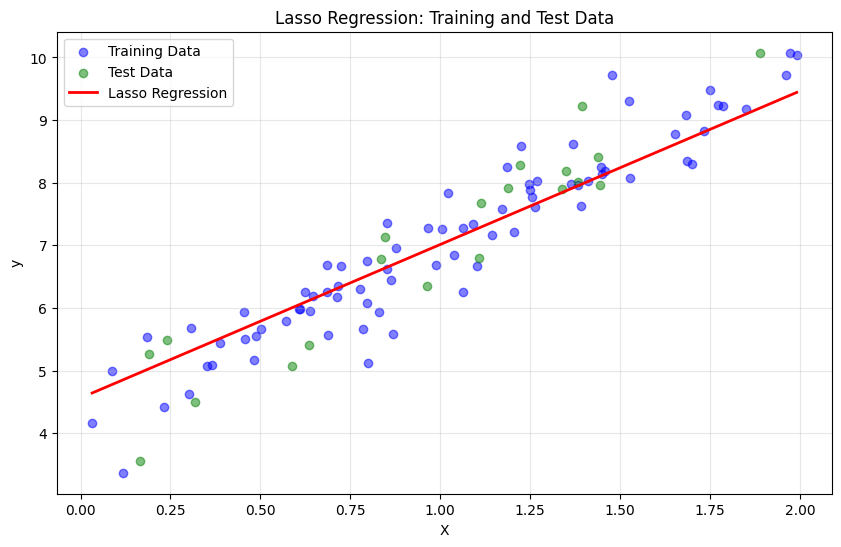

In [9]:
# Memuat perpustakaan
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Hasilkan data sintetis
np.random.seed(123)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) * 0.5

# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Buat dan sesuaikan model regresi Lasso
lasso = Lasso(alpha=0.1)  # alpha is the regularization strength
lasso.fit(X_train, y_train)

# Buatlah prediksi
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

# Hitung metrik
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Cetak metrik
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualisasikan hasilnya
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Urutkan nilai X untuk plot garis halus
X_plot = np.sort(X, axis=0)
y_plot = lasso.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Lasso Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Latihan 3: Menerapkan Regresi ElasticNet
Dalam latihan terakhir ini, kita akan membuat kumpulan data baru dan menyesuaikan model regresi ElasticNet ke dalamnya. Kami kemudian akan mengevaluasi performa model menggunakan metrik mean squared error (MSE) dan R-squared (R^2). Terakhir, kami akan memvisualisasikan prediksi model pada set pengujian untuk melihat seberapa cocok model tersebut dengan data. Jika berlaku, pastikan untuk menggunakan random_state=123 dan/atau np.random.seed(123) untuk memastikan reproduktifitas.

Training Metrics:
MSE: 4.6771
R²: 0.9849

Test Metrics:
MSE: 4.0393
R²: 0.9867


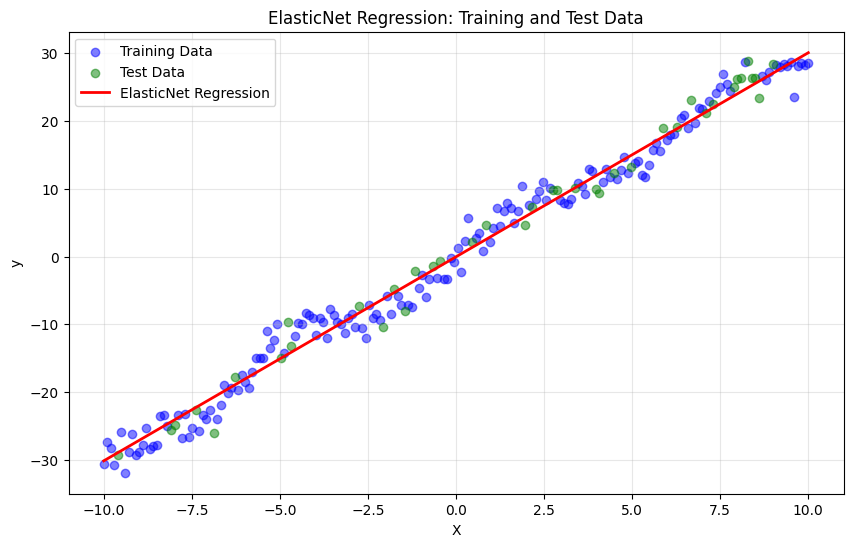

In [10]:
# Memuat perpustakaan
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Hasilkan data sintetis
np.random.seed(123)
X = np.linspace(-10, 10, 200).reshape(-1, 1)
y = 3*X + np.sin(X) * 2 + np.random.normal(0, 1.5, X.shape)

# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Membuat dan menyesuaikan model ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # alpha is regularization strength, l1_ratio balances L1/L2
elastic_net.fit(X_train, y_train)

# Buatlah prediksi
y_pred_train = elastic_net.predict(X_train)
y_pred_test = elastic_net.predict(X_test)

# Hitung metrik
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Cetak metrik
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualisasikan hasilnya
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Urutkan nilai X untuk plot garis halus
X_plot = np.sort(X, axis=0)
y_plot = elastic_net.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='ElasticNet Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('ElasticNet Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita mengeksplorasi model linier untuk regresi beserta teknik pencegahan overfitting (regularisasi):
* **Linear Regression:** Model linier standar tanpa penalti parameter.
* **Ridge Regression (L2 Regularization):** Menambahkan penalti kuadrat koefisien untuk meminimalkan bobot fitur tanpa membuatnya nol.
* **Lasso Regression (L1 Regularization):** Menambahkan penalti nilai mutlak koefisien yang mendorong sparsity (membuat bobot fitur yang kurang penting menjadi nol tepat, berfungsi sebagai penyeleksi fitur otomatis).
* **ElasticNet:** Menggabungkan penalti L1 dan L2 secara proporsional untuk mendapatkan kelebihan dari kedua metode.

#### 2. Pandangan ke Depan
Model regresi linier terregularisasi merupakan landasan penting untuk memodelkan hubungan kontinu. Pada **Bab 6**, kita akan memperluas kerangka kerja model linier ini untuk menangani tugas klasifikasi biner dan multikelas menggunakan Regresi Logistik Lanjutan.